In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
df = pd.read_csv("house_data2.csv")
df.head() 

,Id,Area,Bedrooms,Bathrooms,Floors,Year Built,Location,Condition,Garage,Price
0,1,1360.0,5,4,3,1970.0,Downtown,Excellent,No,149919
1,2,4272.0,5,4,3,1958.0,Downtown,Excellent,No,424998
2,3,3592.0,2,2,3,1938.0,Downtown,Good,No,266746
3,4,966.0,4,2,2,1902.0,Suburban,Fair,Yes,244020
4,5,4926.0,1,4,2,1975.0,Downtown,Fair,Yes,636056


In [ ]:
df.shape 

(2000, 10)

In [ ]:
df.columns 

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Year Built',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [1579]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          2000 non-null   int64  
 1   Area        1999 non-null   float64
 2   Bedrooms    2000 non-null   int64  
 3   Bathrooms   2000 non-null   int64  
 4   Floors      2000 non-null   int64  
 5   Year Built  1999 non-null   float64
 6   Location    2000 non-null   object 
 7   Condition   1998 non-null   object 
 8   Garage      2000 non-null   object 
 9   Price       2000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 156.4+ KB


In [1580]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,Year Built,Price
count,2000.000000,1999.000000,2000.000000,2000.00000,2000.000000,1999.000000,2000.000000
mean,1000.500000,2786.760880,3.003500,2.55250,1.993500,1961.460730,537676.855000
std,577.494589,1295.236051,1.424606,1.10899,0.809188,35.929643,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1652.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2834.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3888.000000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


# EDA

In [1581]:

df.columns = df.columns.str.replace(" ", "_") 

In [1582]:
df.isnull().sum()

Id            0
Area          1
Bedrooms      0
Bathrooms     0
Floors        0
Year_Built    1
Location      0
Condition     2
Garage        0
Price         0
dtype: int64

## Handle Missing Values

📊 Quick Decision Flow
1. Normal → Fill with Mean
2. Skewed / Outliers → Fill with Median
3. Categorical → Fill with Mode

📊 What is Skewness?

Skewness = measure of asymmetry of distribution
- If distribution is symmetric (bell curve), skewness ≈ 0
- If skewness > 0 → Right Skewed (long right tail)
- If skewness < 0 → Left Skewed (long left tail)

📌 Rules of Thumb

1. -0.5 ≤ skewness ≤ 0.5 → Approximately Normal (symmetric) → ✅ Use Mean

2. -1 ≤ skewness < -0.5 or 0.5 < skewness ≤ 1 → Moderately Skewed → Better to use Median
3. Skewness < -1 or > 1 → Highly Skewed → Strongly prefer Median

    Area

In [1583]:

print("Skewness of Area:", df["Area"].skew()) # Skewness for one column
# Calculate stats
print("Mean:", df["Area"].mean())
print("Median:", df["Area"].median())
print("Mode:", df["Area"].mode()[0])

Skewness of Area: -0.03953280476748898
Mean: 2786.7608804402203
Median: 2834.0
Mode: 4219.0


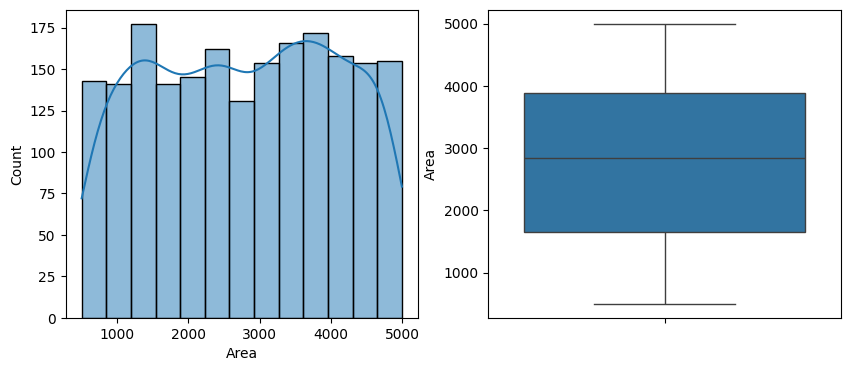

In [1584]:

# Ploting 
plt.figure(figsize=(10,4)) # width , Height
plt.subplot(1,2,1)
sns.histplot(df["Area"], kde=True)


# box plot
plt.subplot(1,2,2)
sns.boxplot(df["Area"])
plt.show()


In [1585]:
area_mean = df["Area"].mean() # calculating mean

df["Area"] = df["Area"].fillna(area_mean) # Fill missing values in Area with mean


In [ ]:
df.isnull().sum() 

Id            0
Area          0
Bedrooms      0
Bathrooms     0
Floors        0
Year_Built    1
Location      0
Condition     2
Garage        0
Price         0
dtype: int64

    YearBuilt

In [1587]:
print(f"Skewness of Year_Built: {df.Year_Built.skew()}")

# Calculate stats
print("Mean:", df["Year_Built"].mean())
print("Median:", df["Year_Built"].median())
print("Mode:", df["Year_Built"].mode()[0])


Skewness of Year_Built: -0.0025329244823445256
Mean: 1961.4607303651826
Median: 1961.0
Mode: 2005.0


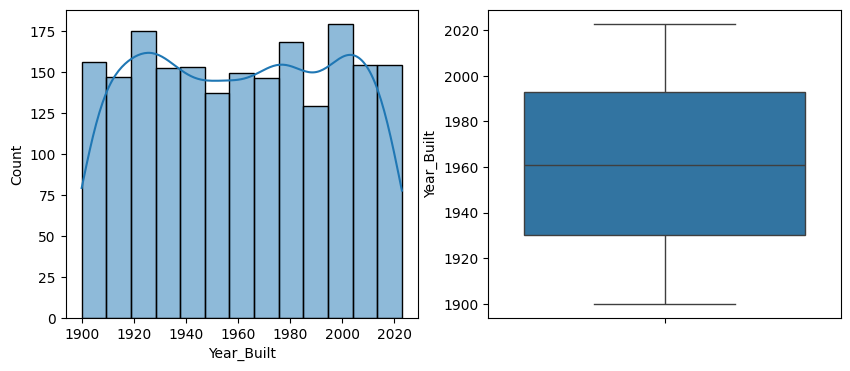

In [1588]:

# Ploting 
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["Year_Built"], kde=True)


plt.subplot(1,2,2)
sns.boxplot(df["Year_Built"])
plt.show()


In [1589]:
Year_mean = df["Year_Built"].mean() # calculating mean

df["Year_Built"] = df["Year_Built"].fillna(Year_mean) # Fill missing values in Year_built with mean


In [ ]:
df.isnull().sum() 

Id            0
Area          0
Bedrooms      0
Bathrooms     0
Floors        0
Year_Built    0
Location      0
Condition     2
Garage        0
Price         0
dtype: int64

    Condition

    - Categorical so filling it with mode

In [1591]:
condition_mode = df["Condition"].mode()[0] # calculating mode
print(condition_mode)

df["Condition"] = df["Condition"].fillna(condition_mode) # Fill missing values with mode

Fair


In [ ]:
df.isnull().sum() 

Id            0
Area          0
Bedrooms      0
Bathrooms     0
Floors        0
Year_Built    0
Location      0
Condition     0
Garage        0
Price         0
dtype: int64

##  Encoding (for categorical data)
- Convert non-numeric features into numeric form.
- Techniques:
   - Label Encoding (ordered categories).
   - One-Hot / Dummy Variables (unordered).
   - Binary Encoding (Yes/No → 1/0).


In [1593]:
df.dtypes

Id              int64
Area          float64
Bedrooms        int64
Bathrooms       int64
Floors          int64
Year_Built    float64
Location       object
Condition      object
Garage         object
Price           int64
dtype: object

In [1594]:
df.head(2)

,Id,Area,Bedrooms,Bathrooms,Floors,Year_Built,Location,Condition,Garage,Price
0,1,1360.0,5,4,3,1970.0,Downtown,Excellent,No,149919
1,2,4272.0,5,4,3,1958.0,Downtown,Excellent,No,424998


    Location
    One Hot encoding

In [1595]:
encoded_location = pd.get_dummies(df["Location"], prefix="Location").astype(int) 
encoded_location.head(3)

,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0


In [1596]:
encoded_location.drop("Location_Suburban", axis=1, inplace=True) # dummy variable trap

encoded_location.head(3)

,Location_Downtown,Location_Rural,Location_Urban
0,1,0,0
1,1,0,0
2,1,0,0


In [1597]:

df.drop("Location", axis=1, inplace=True) # drop the original column


In [1598]:
encoded_location.head(3)

,Location_Downtown,Location_Rural,Location_Urban
0,1,0,0
1,1,0,0
2,1,0,0


In [1599]:
df = pd.concat([df, encoded_location], axis=1)

In [1600]:
df.head(2)

,Id,Area,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Price,Location_Downtown,Location_Rural,Location_Urban
0,1,1360.0,5,4,3,1970.0,Excellent,No,149919,1,0,0
1,2,4272.0,5,4,3,1958.0,Excellent,No,424998,1,0,0


    Condition
    ordinal Encoding

In [1601]:
df["Condition"].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [1602]:
cond_order = {
    "Poor":1, 
    "Fair":2,
    "Good":3,
    "Excellent":4
}

df["Condition"] = df["Condition"].map(cond_order)

In [1603]:
df.head(3)

,Id,Area,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Price,Location_Downtown,Location_Rural,Location_Urban
0,1,1360.0,5,4,3,1970.0,4,No,149919,1,0,0
1,2,4272.0,5,4,3,1958.0,4,No,424998,1,0,0
2,3,3592.0,2,2,3,1938.0,3,No,266746,1,0,0


    Garage
    Binary Encoding

In [1604]:
df["Garage"].unique()

array(['No', 'Yes'], dtype=object)

In [1605]:
df["Garage"] = df["Garage"].map({"Yes": 1, "No": 0})
df.head(2)

,Id,Area,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Price,Location_Downtown,Location_Rural,Location_Urban
0,1,1360.0,5,4,3,1970.0,4,0,149919,1,0,0
1,2,4272.0,5,4,3,1958.0,4,0,424998,1,0,0


In [1606]:
df = df.astype(int)

In [1607]:
df.head(2)

,Id,Area,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Price,Location_Downtown,Location_Rural,Location_Urban
0,1,1360,5,4,3,1970,4,0,149919,1,0,0
1,2,4272,5,4,3,1958,4,0,424998,1,0,0


# 6. Feature Selection
- Keep only the most relevant features.
- Use:
    - Correlation heatmap.
    - Statistical tests (ANOVA, Chi-square).
    - Model-based feature importance (RandomForest, Lasso).


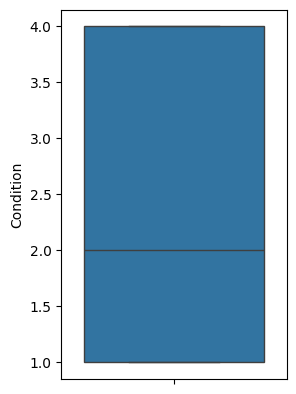

In [1608]:

plt.subplot(1,2,2)
sns.boxplot(df["Condition"])
plt.show()


In [1609]:
df.head(2)

,Id,Area,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Price,Location_Downtown,Location_Rural,Location_Urban
0,1,1360,5,4,3,1970,4,0,149919,1,0,0
1,2,4272,5,4,3,1958,4,0,424998,1,0,0


In [1610]:
df.drop("Id", axis=1, inplace=True) # delete Id, not required
df.drop("Year_Built", axis=1, inplace=True) # delete Id, not required

In [ ]:
y = df["Price"]# Target Variable
X = df[["Area"]]

# X = df.drop("Price", axis=1) # input features

In [1612]:
y.head(2)

0    149919
1    424998
Name: Price, dtype: int64

In [1613]:

X.head(2)

,Area
0,1360
1,4272


# 7. Train-Test Split
- Split data into:
    - Training set (70–80%) → model learns patterns.
    - Testing set (20–30%) → evaluate performance.


In [ ]:
from sklearn.model_selection import train_test_split

# split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 8. Feature Scaling
- Normalize/standardize numeric features (e.g., exam scores, study hours).
- Prevents one feature (like “Income”) from dominating another (like “Study Hours”).
- Techniques:
    - MinMaxScaler → scales between 0–1.
    - StandardScaler → mean = 0, std = 1.


In [ ]:
# from sklearn.preprocessing import StandardScaler
# # scale after split
# scaler = StandardScaler() 
# X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
# X_test_scaled  = scaler.transform(X_test)        # only transform on test


## 9. Model Selection (Choose Appropriate ML Algo) & Training
- Regression → Linear Regression, Random Forest Regressor, XGBoost, etc.
- Classification → Logistic Regression, SVM, Decision Tree, etc.


In [ ]:
from sklearn.linear_model import LinearRegression

# initialize model
model = LinearRegression()

# train model
model.fit(X_train, y_train)

# predict on test set
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# 4. Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 243554.2656129729
MSE: 79003848228.77763
RMSE: 281076.2320595209
R² Score: -0.0006118583697358737
